In [2]:
import numpy as np
from obspy.taup import TauPyModel
from obspy.geodetics import locations2degrees

# -------------------- params --------------------
RMOON_KM     = 1737.1
SOURCE_DEPTH = 30
PHASE_LIST   = ["P"]
MODEL_NAME   = "vpremoon_mantle_closed"
PLOT_FIRST_ARRIVAL_ONLY = True
CORE_RADIUS_KM = 350.0


def lat_along_great_circle(src_lat, src_lon, rec_lat, rec_lon, f):
    """
    Great-circle latitude at fraction f in [0,1] between endpoints
    using spherical linear interpolation (slerp) on unit vectors.
    Returns latitude in radians.
    """
    # degrees -> radians
    lat1, lon1 = np.deg2rad([src_lat, src_lon])
    lat2, lon2 = np.deg2rad([rec_lat, rec_lon])

    def sph2cart(lat, lon):
        return np.array([
            np.cos(lat) * np.cos(lon),
            np.cos(lat) * np.sin(lon),
            np.sin(lat)
        ])

    a = sph2cart(lat1, lon1)
    b = sph2cart(lat2, lon2)

    # angle between vectors
    omega = np.arccos(np.clip(np.dot(a, b), -1.0, 1.0))
    if omega < 1e-12:
        # same point
        return lat1

    so = np.sin(omega)
    x = (np.sin((1 - f) * omega) / so) * a + (np.sin(f * omega) / so) * b
    x /= np.linalg.norm(x)

    lat = np.arcsin(np.clip(x[2], -1.0, 1.0))
    return lat

def deltaT_degree1_coslat(
    model_name,
    phase,
    src_depth_km,
    src_lat, src_lon,
    rec_lat, rec_lon,
    eps
):
    model = TauPyModel(model=model_name)

    # epicentral distance in degrees for TauP
    dist_deg = locations2degrees(src_lat, src_lon, rec_lat, rec_lon)

    arrs = model.get_ray_paths(
        source_depth_in_km=src_depth_km,
        distance_in_degree=dist_deg,
        phase_list=[phase]
    )
    if not arrs:
        raise RuntimeError("No arrivals returned (phase not found / geometry issue).")

    a = arrs[0]
    path = a.path  # typically has fields: time, dist, depth (dist often in radians)

    # TauP path dist is usually in radians; total distance is dist_deg in degrees.
    # We can normalize by the max dist in the path array instead of trusting units.
    dist_path = np.asarray(path["dist"], dtype=float)
    time_path = np.asarray(path["time"], dtype=float)

    # Ensure increasing
    order = np.argsort(time_path)
    dist_path = dist_path[order]
    time_path = time_path[order]

    # Fraction along the path using dist coordinate
    dist0 = dist_path[0]
    dist1 = dist_path[-1]
    if abs(dist1 - dist0) < 1e-12:
        raise RuntimeError("Degenerate path distance sampling.")

    f = (dist_path - dist0) / (dist1 - dist0)

    # Compute latitude at each sample (great-circle interpolation)
    lat_i = np.array([lat_along_great_circle(src_lat, src_lon, rec_lat, rec_lon, fi) for fi in f])

    # Discrete integral: δT ≈ -eps Σ cos(lat_i) Δt_i
    dt = np.diff(time_path)
    coslat_mid = np.cos(0.5 * (lat_i[:-1] + lat_i[1:]))  # midpoint rule
    deltaT = -eps * np.sum(coslat_mid * dt)

    return a.time, deltaT, a.time + deltaT

# Example call:
T0, dT, Tcorr = deltaT_degree1_coslat(
    model_name="iasp91",
    phase="P",
    src_depth_km=50,
    src_lat=10, src_lon=20,
    rec_lat=50, rec_lon=80,
    eps=0.02
)
print("TauP T0:", T0, "s  deltaT:", dT, "s  corrected:", Tcorr, "s")

TauP T0: 623.4927226270956 s  deltaT: -10.247726487255768 s  corrected: 613.2449961398398 s


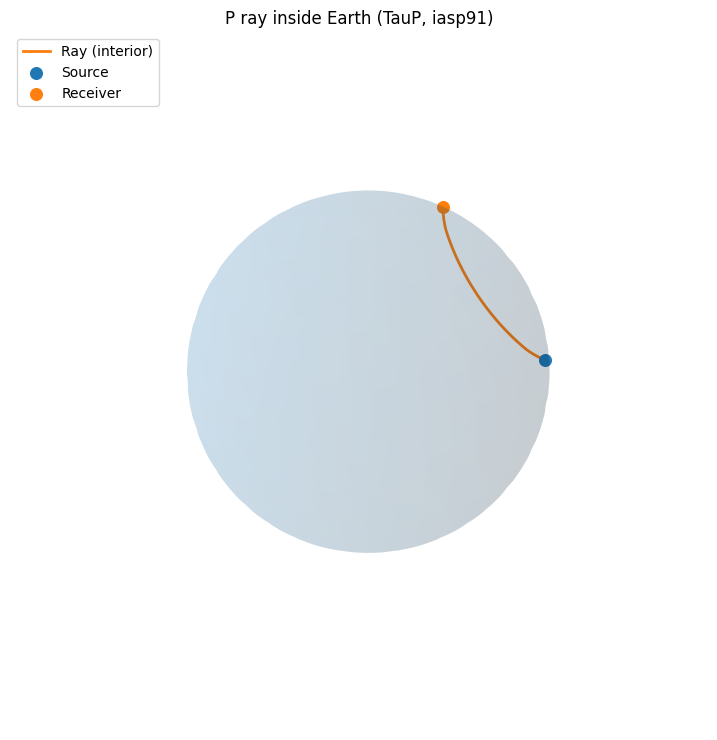

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from obspy.taup import TauPyModel
from obspy.geodetics import locations2degrees

# --- geometry helpers ---
def sph2cart(lat_rad, lon_rad, r=1.0):
    return np.array([
        r*np.cos(lat_rad)*np.cos(lon_rad),
        r*np.cos(lat_rad)*np.sin(lon_rad),
        r*np.sin(lat_rad),
    ])

def great_circle_slerp_unit(src_lat_deg, src_lon_deg, rec_lat_deg, rec_lon_deg, f_array):
    """
    Slerp on unit sphere between source and receiver.
    f_array in [0,1]. Returns unit vectors (N,3) and lat/lon arrays (rad).
    """
    lat1, lon1 = np.deg2rad([src_lat_deg, src_lon_deg])
    lat2, lon2 = np.deg2rad([rec_lat_deg, rec_lon_deg])

    a = sph2cart(lat1, lon1, r=1.0)
    b = sph2cart(lat2, lon2, r=1.0)

    omega = np.arccos(np.clip(np.dot(a, b), -1.0, 1.0))
    if omega < 1e-12:
        u = np.repeat(a[None, :], len(f_array), axis=0)
        lat = np.full(len(f_array), lat1)
        lon = np.full(len(f_array), lon1)
        return u, lat, lon

    so = np.sin(omega)
    u = np.empty((len(f_array), 3), dtype=float)

    for k, f in enumerate(f_array):
        x = (np.sin((1 - f) * omega) / so) * a + (np.sin(f * omega) / so) * b
        u[k] = x / np.linalg.norm(x)

    lat = np.arcsin(np.clip(u[:, 2], -1.0, 1.0))
    lon = np.arctan2(u[:, 1], u[:, 0])
    return u, lat, lon

def plot_3d_ray_inside_sphere(ray_xyz, src_xyz, rec_xyz, R=6371.0, title="TauP ray inside spherical Earth"):
    # sphere mesh
    u = np.linspace(0, 2*np.pi, 120)
    v = np.linspace(-np.pi/2, np.pi/2, 60)
    UU, VV = np.meshgrid(u, v)
    xs = R*np.cos(VV)*np.cos(UU)
    ys = R*np.cos(VV)*np.sin(UU)
    zs = R*np.sin(VV)

    fig = plt.figure(figsize=(7.5, 7.5))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(xs, ys, zs, linewidth=0, antialiased=True, alpha=0.12)

    ax.plot(ray_xyz[:, 0], ray_xyz[:, 1], ray_xyz[:, 2], linewidth=2, label="Ray (interior)")
    ax.scatter([src_xyz[0]], [src_xyz[1]], [src_xyz[2]], s=70, label="Source")
    ax.scatter([rec_xyz[0]], [rec_xyz[1]], [rec_xyz[2]], s=70, label="Receiver")

    ax.set_title(title)
    ax.set_box_aspect((1, 1, 1))
    ax.set_axis_off()
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

# --- main: get TauP ray, convert to 3D points ---
def taup_ray_xyz(model_name, phase, src_depth_km, src_lat, src_lon, rec_lat, rec_lon, R=6371.0):
    model = TauPyModel(model=model_name)
    dist_deg = locations2degrees(src_lat, src_lon, rec_lat, rec_lon)

    arrs = model.get_ray_paths(
        source_depth_in_km=src_depth_km,
        distance_in_degree=dist_deg,
        phase_list=[phase]
    )
    if not arrs:
        raise RuntimeError("No ray returned for this phase/geometry.")

    a = arrs[0]
    path = a.path

    # TauP sample arrays
    time = np.asarray(path["time"], dtype=float)
    dist = np.asarray(path["dist"], dtype=float)   # angular distance coordinate along ray
    depth = np.asarray(path["depth"], dtype=float) # km

    # sort by time in case
    idx = np.argsort(time)
    dist = dist[idx]
    depth = depth[idx]

    # Convert dist samples to fraction along the great circle from source to receiver.
    # We normalize by the dist coordinate itself, so we don't care if it's radians or degrees.
    f = (dist - dist[0]) / (dist[-1] - dist[0] + 1e-15)
    f = np.clip(f, 0.0, 1.0)

    # Unit direction vectors along great circle
    uvec, _, _ = great_circle_slerp_unit(src_lat, src_lon, rec_lat, rec_lon, f)

    # Radius at each sample point
    r = R - depth
    ray_xyz = uvec * r[:, None]

    # Source and receiver points on their radii
    src_xyz = sph2cart(np.deg2rad(src_lat), np.deg2rad(src_lon), r=R - src_depth_km)
    rec_xyz = sph2cart(np.deg2rad(rec_lat), np.deg2rad(rec_lon), r=R - 0.0)

    return a, ray_xyz, src_xyz, rec_xyz

# --- example usage ---
# Define your event/station
src_lat, src_lon, src_depth_km = 10.0, 20.0, 50.0
rec_lat, rec_lon = 50.0, 80.0

a, ray_xyz, src_xyz, rec_xyz = taup_ray_xyz(
    model_name="iasp91",
    phase="P",
    src_depth_km=src_depth_km,
    src_lat=src_lat, src_lon=src_lon,
    rec_lat=rec_lat, rec_lon=rec_lon,
    R=6371.0
)

plot_3d_ray_inside_sphere(ray_xyz, src_xyz, rec_xyz, R=6371.0,
                          title=f"{a.name} ray inside Earth (TauP, iasp91)")